In [12]:
import os
import cv2
import time
import random
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skimage import feature
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, GridSearchCV
from scipy.stats import skew, kurtosis

In [13]:
IMG_SIZE = (222, 222)
NUM_AUGMENTATIONS_PER_IMAGE = 3
random.seed(42)
np.random.seed(42)
# LABELS = np.array(['Bacterialblight', 'Blast', 'Brownspot', 'Healthy', 'Tungro'])
# LABELS = np.array(['Hispa', 'LeafBlast', 'BrownSpot', 'Healthy'])
dataset_path = 'datasets/local_dataset_no_duplicate'
is_train_splitted = False
LABELS = np.array(os.listdir(f'{dataset_path}/train_images')) if is_train_splitted else np.array(os.listdir(dataset_path))
MAIN_DATASET = [dataset_path, 1400]
ADDITIONAL_DATASET = [['paddy-disease-classification-healthy', 1700],['rice_leaves_disease', 305]]
# ADDITIONAL_DATASET = [['leaf-rice-disease-indonesia', 80], ['rice_leaves_disease', 305]]
TRAIN_SPLIT_RATIO = 0.9
N_SPLITS = 5
# TEST_SPLIT_RATIO = 0.5 
EXPERIMENT_NAME = '251121 0352 Mixed On Field Healthy'
TEST_DATA_PATH = f'datasets/result/{EXPERIMENT_NAME}/test_images'
augmented_dataset_path = f'datasets/result/{EXPERIMENT_NAME}/augmented_images'

RESULT_DICT_PATH = f'Results/{EXPERIMENT_NAME}'
SCALER_PATH = os.path.join(RESULT_DICT_PATH, 'scaler.pkl')
PCA_PATH = os.path.join(RESULT_DICT_PATH, 'pca.pkl')
SVM_MODEL_PATH = os.path.join(RESULT_DICT_PATH, 'svm_model.pkl')
RF_MODEL_PATH = os.path.join(RESULT_DICT_PATH, 'rf_model.pkl')
KNN_MODEL_PATH = os.path.join(RESULT_DICT_PATH, 'knn_model.pkl')

In [14]:
def show_class_distribution(labels, title="Class Distribution"):
    """Menampilkan distribusi kelas dalam data label."""
    class_counts = {class_name: labels.count(class_name) for class_name in LABELS}
    
    # Mempersiapkan data untuk plot
    counts = [class_counts[name] for name in LABELS]
    
    # Menampilkan plot
    plt.figure(figsize=(10, 6))
    bars = plt.bar(LABELS, counts, color='blue')
    
    # Menambahkan angka di atas setiap batang
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')
        
    plt.title(title, fontsize=16)
    plt.xlabel("Nama Kelas", fontsize=12)
    plt.ylabel("Jumlah Gambar", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

In [15]:
# Load data
def load_images_from_directory(base_path, limit=1000):
    data = []
    labels = []
    for folder_name in LABELS:
        data_length = len(data)
        folder_path = os.path.join(base_path, folder_name)
        if not os.path.exists(folder_path):
            print(f"Directory not found: {folder_path}")
            continue
        
        print(len(os.listdir(folder_path)), "images in", folder_name)
        for i, filename in enumerate(os.listdir(folder_path)):
            if i == limit: break
            image_path = os.path.join(folder_path, filename)
            img = cv2.imread(image_path)
            if img is None:
                print(f"Failed to load image: {image_path}")
                continue

            data.append(cv2.resize(img, IMG_SIZE))
            labels.append(folder_name)
        print(f"Loaded {len(data)-data_length} images from {folder_name}")
    print('dataset loaded')
    print('dataset len:', len(data))
    print('labels len:', len(labels))
    return np.array(data), np.array(labels)


In [16]:
dataset, labels = load_images_from_directory(dataset_path, MAIN_DATASET[1])

1326 images in bacterial_leaf_blight
Loaded 1326 images from bacterial_leaf_blight
960 images in blast
Loaded 960 images from blast
1200 images in brown_spot
Loaded 1200 images from brown_spot
0 images in normal
Loaded 0 images from normal
1308 images in tungro
Loaded 1308 images from tungro
dataset loaded
dataset len: 4794
labels len: 4794


In [17]:
for additional_dataset in ADDITIONAL_DATASET:
    print(f"Loading additional dataset from {additional_dataset[0]}")
    extra_dataset, extra_labels = load_images_from_directory(f'datasets/{additional_dataset[0]}', additional_dataset[1])
    dataset = np.concatenate((dataset, extra_dataset), axis=0)
    labels = np.concatenate((labels, extra_labels), axis=0)

print('extra dataset loaded')
print('dataset shape:', dataset.shape)
print('labels shape:', labels.shape)

Loading additional dataset from paddy-disease-classification-healthy
Directory not found: datasets/paddy-disease-classification-healthy\bacterial_leaf_blight
Directory not found: datasets/paddy-disease-classification-healthy\blast
Directory not found: datasets/paddy-disease-classification-healthy\brown_spot
1764 images in normal
Loaded 1700 images from normal
Directory not found: datasets/paddy-disease-classification-healthy\tungro
dataset loaded
dataset len: 1700
labels len: 1700
Loading additional dataset from rice_leaves_disease
180 images in bacterial_leaf_blight
Loaded 180 images from bacterial_leaf_blight
305 images in blast
Loaded 305 images from blast
267 images in brown_spot
Loaded 267 images from brown_spot
157 images in normal
Loaded 157 images from normal
Directory not found: datasets/rice_leaves_disease\tungro
dataset loaded
dataset len: 909
labels len: 909
extra dataset loaded
dataset shape: (7403, 222, 222, 3)
labels shape: (7403,)


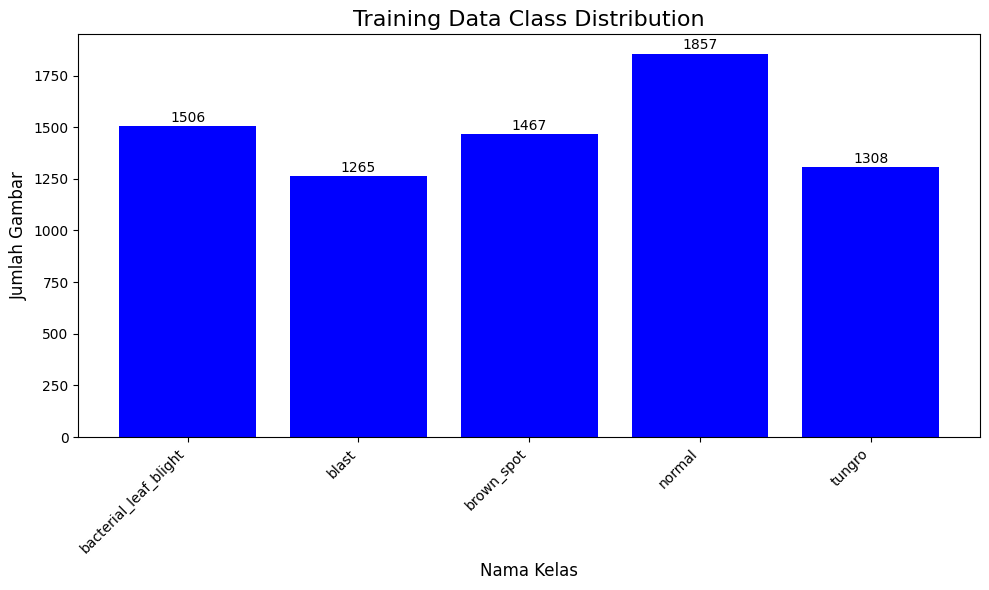

In [18]:
show_class_distribution(labels.tolist(), title="Training Data Class Distribution")

In [19]:
permutation_indices = np.random.permutation(len(dataset))
dataset = dataset[permutation_indices]
labels = labels[permutation_indices]

In [20]:
def split_dataset_by_class(dataset, labels, num_test_per_class):
    """
    Splits the dataset into training and testing sets with a fixed number
    of test samples per class.

    Args:
        dataset (np.ndarray): The feature data of the entire dataset.
        labels (np.ndarray): The labels of the entire dataset.
        num_test_per_class (int): The fixed number of test samples for each class.

    Returns:
        tuple: A tuple containing X_train, X_test, y_train, y_test.
    """
    print(f"--- Splitting dataset with a fixed test size of {num_test_per_class} per class ---")
    
    # Get unique classes and their indices
    # unique_classes = np.unique(LABELS)
    
    # Initialize lists to store the split data
    X_train_list, X_test_list = [], []
    y_train_list, y_test_list = [], []
    
    # Iterate through each unique class
    for label in LABELS:
        # Find the indices of samples belonging to the current class
        class_indices = np.where(labels == label)[0]
        class_dataset = dataset[class_indices]
        class_labels = labels[class_indices]
        
        # Check if the class has enough samples for the test set
        if len(class_dataset) < num_test_per_class:
            print(f"Warning: Class {label} has fewer than {num_test_per_class} samples. It will be entirely used for testing.")
            # Use all samples for testing if not enough
            X_test_list.append(class_dataset)
            y_test_list.append(class_labels)
            
        else:
            # Perform a stratified split for the current class
            X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
                class_dataset,
                class_labels,
                test_size=num_test_per_class,
                random_state=42,
                stratify=class_labels
            )
            
            # Append the results to the lists
            X_train_list.append(X_train_class)
            X_test_list.append(X_test_class)
            y_train_list.append(y_train_class)
            y_test_list.append(y_test_class)
    
    # Concatenate the split data from all classes
    X_train = np.concatenate(X_train_list, axis=0)
    X_test = np.concatenate(X_test_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    y_test = np.concatenate(y_test_list, axis=0)
    
    return X_train, X_test, y_train, y_test

In [21]:
X_train, X_test, y_train, y_test = split_dataset_by_class(dataset, labels, num_test_per_class=200)

--- Splitting dataset with a fixed test size of 200 per class ---


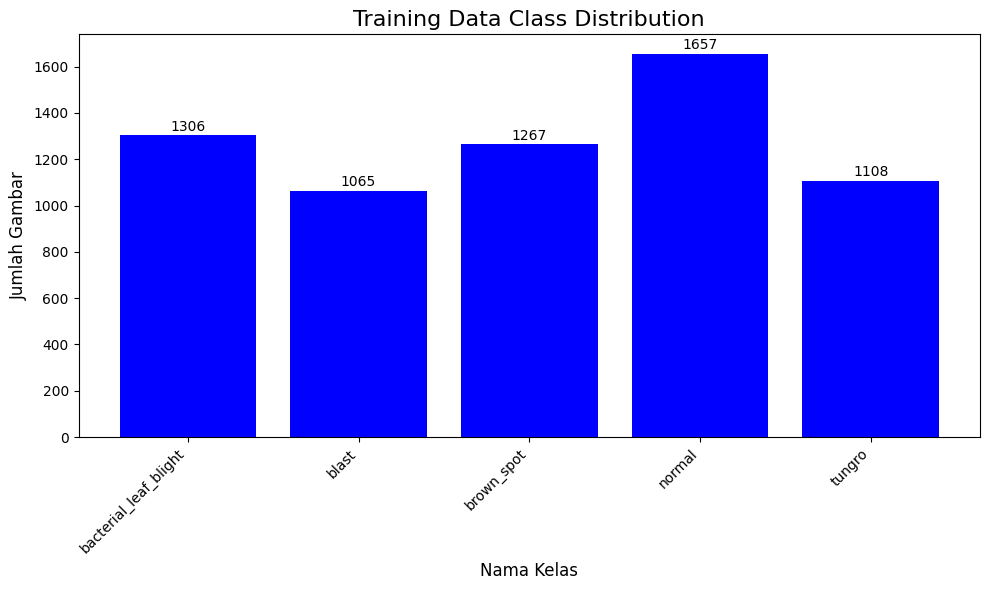

In [22]:
show_class_distribution(y_train.tolist(), title="Training Data Class Distribution")

In [23]:
# X_train, X_test, y_train, y_test = train_test_split(dataset, labels, train_size=TRAIN_SPLIT_RATIO, random_state=42)
# X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, train_size=TEST_SPLIT_RATIO, random_state=42)

In [24]:
# Save test data from splitted dataset
def save_data(X, y, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    for i, (image, label) in enumerate(zip(X, y)):
        if not os.path.exists(f"{output_dir}/{label}"):
            os.makedirs(f"{output_dir}/{label}")
        image_path = os.path.join(output_dir, f"{label}/{label}_{i}.jpg")
        cv2.imwrite(image_path, image)
        
save_data(X_test, y_test, TEST_DATA_PATH)

In [25]:
# X_train, y_train = load_images_from_directory(f'{dataset_path}/train_images/', LIMIT)
# X_test, y_test = load_images_from_directory(f'{dataset_path}/test_images/', LIMIT)
# X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, train_size=TEST_SPLIT_RATIO, random_state=42)

In [26]:
# if len(LABELS) < 5: cols = len(LABELS)
# else: cols = 5
# row = (len(LABELS) // 5)+1

# fig = plt.figure(figsize=(15, 6))
# for j in range(len(LABELS)):
#     fig.add_subplot(row, cols, j+1)
#     index = np.where(labels == LABELS[j])[0][0]
#     plt.imshow(cv2.cvtColor(dataset[index], cv2.COLOR_BGR2RGB))
#     plt.axis('off') 
#     plt.title(LABELS[j])

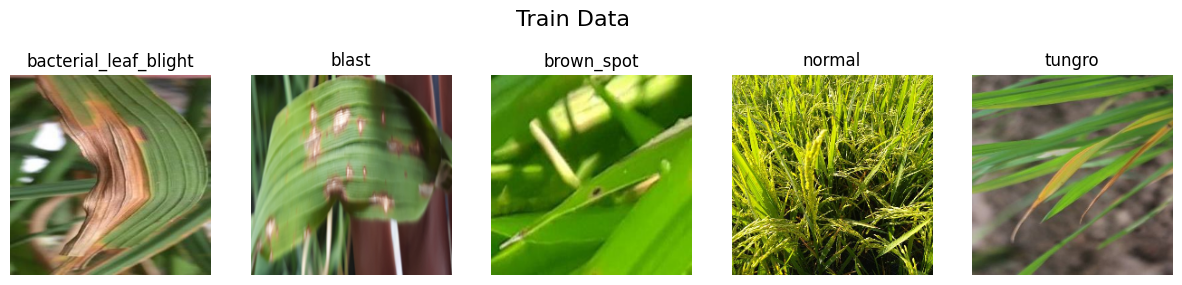

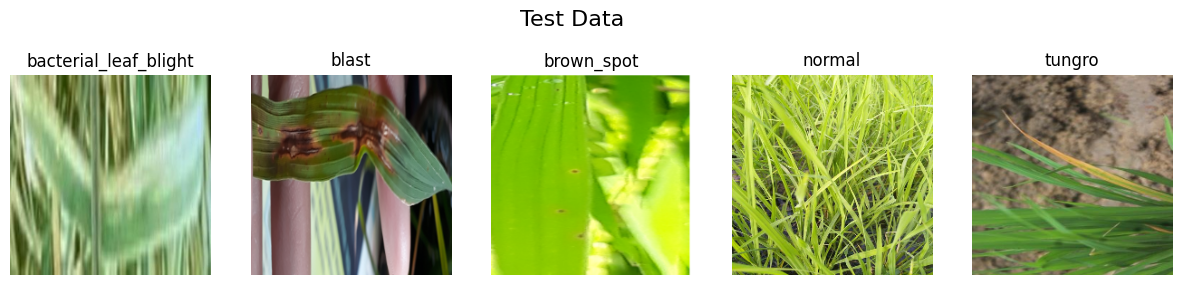

In [27]:
fig = plt.figure(figsize=(15, 6))

fig.suptitle('Train Data', fontsize=16)

if len(LABELS) < 5: cols = len(LABELS)
else: cols = 5

row = (len(LABELS) // 5)+1

for j in range(len(LABELS)):
    fig.add_subplot(row, cols, j+1)
    index = np.where(y_train == LABELS[j])[0][0]
    plt.imshow(cv2.cvtColor(X_train[index], cv2.COLOR_BGR2RGB))
    plt.axis('off') 
    plt.title(LABELS[j])


fig = plt.figure(figsize=(15, 6))

fig.suptitle('Test Data', fontsize=16)

for j in range(len(LABELS)):
    fig.add_subplot(row, cols, j+1)
    index = np.where(y_test == LABELS[j])[0][0]
    plt.imshow(cv2.cvtColor(X_test[index], cv2.COLOR_BGR2RGB))
    plt.axis('off') 
    plt.title(LABELS[j])

# Pre-Processing


In [28]:
def normalize_image(image):
    nmax = 255 #New maximum
    nmin = 0 #New minimum
    return cv2.normalize(image,None,alpha = nmin,beta = nmax,norm_type = cv2.NORM_MINMAX)

In [29]:
def rotate_image(image, angle):
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    # Menggunakan BORDER_REPLICATE untuk mengisi piksel kosong dengan piksel tepi terdekat
    rotated = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
    return rotated

In [30]:
def translate_image(image, dx, dy):
    (h, w) = image.shape[:2]
    M = np.float32([[1, 0, dx], [0, 1, dy]])
    translated = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
    return translated

In [31]:
def zoom_image(image, zoom_factor):
    # Resize gambar sesuai faktor zoom
    resized = cv2.resize(image, None, fx=zoom_factor, fy=zoom_factor, interpolation=cv2.INTER_LINEAR)

    # Jika hasil zoom lebih besar dari IMG_SIZE, crop bagian tengah
    if resized.shape[0] > IMG_SIZE[0] or resized.shape[1] > IMG_SIZE[1]:
        start_row = (resized.shape[0] - IMG_SIZE[0]) // 2
        end_row = start_row + IMG_SIZE[0]
        start_col = (resized.shape[1] - IMG_SIZE[1]) // 2
        end_col = start_col + IMG_SIZE[1]
        cropped = resized[start_row:end_row, start_col:end_col]
        return cropped
    # Jika hasil zoom lebih kecil, tambahkan padding (ini yang menghasilkan piksel kosong)
    else:
        top = (IMG_SIZE[0] - resized.shape[0]) // 2
        bottom = IMG_SIZE[0] - resized.shape[0] - top
        left = (IMG_SIZE[1] - resized.shape[1]) // 2
        right = IMG_SIZE[1] - resized.shape[1] - left
        # Mengisi dengan piksel tepi terdekat
        padded = cv2.copyMakeBorder(resized, top, bottom, left, right, borderType=cv2.BORDER_REPLICATE)
        return padded

In [32]:
def adjust_brightness(image):
    """Menyesuaikan kecerahan dengan nilai acak antara -30 dan 30."""
    value = random.randint(-30, 30)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    v_new = np.clip(cv2.add(v, value), 0, 255)
    final_hsv = cv2.merge([h, s, v_new])
    bright_image = cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)
    return bright_image

def adjust_contrast(image):
    """Menyesuaikan kontras dengan faktor acak antara 0.8 dan 1.2."""
    factor = random.uniform(0.8, 1.2)
    contrast_image = np.clip(cv2.convertScaleAbs(image, alpha=factor, beta=0), 0, 255)
    return contrast_image

def adjust_saturation(image):
    """Menyesuaikan saturasi dengan faktor acak antara 0.8 dan 1.2."""
    factor = random.uniform(0.8, 1.2)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    s_new = np.clip(cv2.multiply(s.astype(np.float32), factor), 0, 255).astype(np.uint8)
    final_hsv = cv2.merge([h, s_new, v])
    saturated_image = cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)
    return saturated_image

def adjust_hue(image):
    """Menyesuaikan rona dengan nilai acak antara -10 dan 10."""
    value = random.randint(-10, 10)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    h_new = (h.astype(int) + value) % 180
    final_hsv = cv2.merge([h_new.astype(np.uint8), s, v])
    hue_image = cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)
    return hue_image

def adjust_gamma(image):
    """Menerapkan koreksi gamma dengan nilai gamma acak antara 0.7 dan 1.5."""
    gamma = random.uniform(0.7, 1.5)
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(image, table)

def add_gaussian_noise(image):
    """Menambahkan Gaussian noise dengan mean 0 dan varians acak hingga 0.02."""
    mean = 0
    var = random.uniform(0, 0.02)
    sigma = var ** 0.5
    image_float = image.astype(np.float32) / 255.0
    gauss = np.random.normal(mean, sigma, image_float.shape)
    noisy_image = np.clip(image_float + gauss, 0, 1)
    return (noisy_image * 255).astype(np.uint8)

In [33]:
def get_balancer_amount(max_amount):
    return {f'{class_name}': max_amount-y_train.tolist().count(class_name) for class_name in LABELS}

In [34]:
def augment_images(X, y):
    augmentation_functions = [
        adjust_brightness, adjust_contrast, adjust_saturation,
        adjust_hue, adjust_gamma, add_gaussian_noise
    ]
    
    balancer_amount = get_balancer_amount(6000)
    
    for class_name, amount in balancer_amount.items():
        write_path = f"{augmented_dataset_path}/{class_name}/"
        os.makedirs(f'{write_path}', exist_ok=True)
        
        indices = np.where(y == class_name)[0]
        original_images_for_class = X[indices]
    
        image_pool = list(original_images_for_class)
        random.shuffle(image_pool)

        for i in range(amount):
            # Jika kolam kosong, isi ulang dan acak kembali
            if not image_pool:
                image_pool = list(original_images_for_class)
                random.shuffle(image_pool)
            
            # Ambil dan hapus satu gambar dari kolam
            original_image = image_pool.pop()
            
            # Pilih fungsi augmentasi secara acak
            aug_func = random.choice(augmentation_functions)
            augmented_image = aug_func(original_image)
            
            # Tambahkan hasil ke list
            cv2.imwrite(f"{write_path}/{i}_augmented_{aug_func.__name__}.jpg", augmented_image)
    
    # for i, img in enumerate(X):
    #     # for _ in range(NUM_AUGMENTATIONS_PER_IMAGE):
    #     augmented_img = {
    #         "rleft": rotate_image(img.copy(), 90),
    #         "rright": rotate_image(img.copy(), -90),
    #         "r180": rotate_image(img.copy(), 180),
    #         "fhorizon": cv2.flip(img.copy(), 1),
    #         "fvertical": cv2.flip(img.copy(), 0),
    #     }
        
    #     write_path = f"{augmented_dataset_path}/{y[i]}/"
    #     os.makedirs(f'{write_path}', exist_ok=True)
    #     # cv2.imwrite(f"{write_path}/augmented_image_{i}_{_}.jpg", augmented_img)
    #     for _ , augmented_img in augmented_img.items():
    #         cv2.imwrite(f"{write_path}/{i}_augmented_{_}.jpg", augmented_img)

In [35]:
augment_images(X_train, y_train)

In [36]:
augmented_X_train, augmented_y_train = load_images_from_directory(augmented_dataset_path, 8285)

X_train = np.append(X_train, augmented_X_train, axis=0)
y_train = np.append(y_train, augmented_y_train)

4694 images in bacterial_leaf_blight
Loaded 4694 images from bacterial_leaf_blight
4935 images in blast
Loaded 4935 images from blast
4733 images in brown_spot
Loaded 4733 images from brown_spot
4343 images in normal
Loaded 4343 images from normal
4892 images in tungro
Loaded 4892 images from tungro
dataset loaded
dataset len: 23597
labels len: 23597


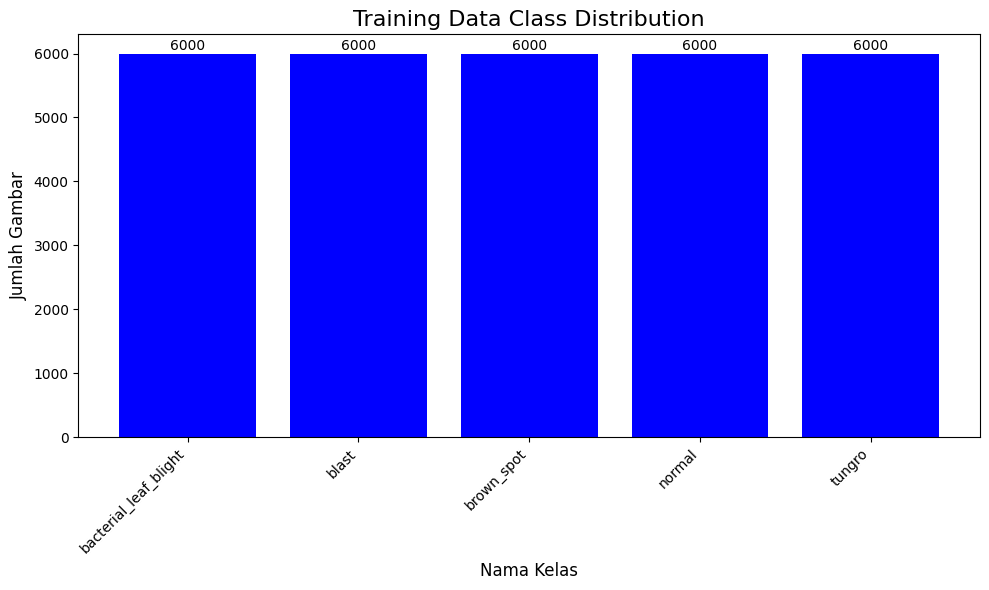

In [37]:
show_class_distribution(y_train.tolist(), title="Training Data Class Distribution")

In [38]:
# print(f"Total training images after augmentation: {len(X_train)}")

In [39]:
# def segment_image(image, label):
def segment_image(image):
    hsv_img = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # fig = plt.figure(figsize=(9, 6))

    # plt.axis('off') 
    # plt.title(label)
    # plt.imshow(cv2.cvtColor(mask2*255, cv2.COLOR_BGR2RGB))
    
    lower_yellow = np.array([ 15, 0, 56])  # Adjust as needed
    upper_yellow = np.array([32, 255, 255])  # Adjust as
    
    lower_chocolate = np.array([0, 10, 0])
    upper_chocolate = np.array([15, 255, 255])
    
    yellow_mask = cv2.inRange(hsv_img, lower_yellow, upper_yellow)
    dark_chocolate_mask = cv2.inRange(hsv_img, lower_chocolate, upper_chocolate)
    
    mask3 = cv2.bitwise_or(yellow_mask, dark_chocolate_mask)
    mask3 = cv2.dilate(mask3, None, iterations=1)
    mask3 = cv2.erode(mask3, None, iterations=1)
    result = cv2.bitwise_and(image, image, mask=mask3)
    
    # mask = np.zeros(image.shape[:2], np.uint8)
    # bgModel = np.zeros((1, 65), np.float64)
    # fgModel = np.zeros((1, 65), np.float64)

    # # Rectangle awal perkiraan daun
    # rect = (1, 1, 225, 225)
    # cv2.grabCut(image, mask, rect, bgModel, fgModel, 8, cv2.GC_INIT_WITH_RECT)

    # mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")
    # result = cv2.bitwise_and(result, result, mask=mask2)
    
    # print(mask3.max(), image.shape)
    
    # fig = plt.figure(figsize=(9, 6))

    # plt.axis('off') 
    # plt.title(label)
    # plt.imshow(cv2.cvtColor(mask3, cv2.COLOR_BGR2RGB))
    
    return result
    # return mask

In [40]:
# segementation_test = segment_image(X_train[0])

# fig = plt.figure(figsize=(9, 6))

# plt.imshow(cv2.cvtColor(X_train[0], cv2.COLOR_BGR2RGB))
# plt.axis('off') 
# plt.title(y_train[0])

# fig = plt.figure(figsize=(9, 6))

# plt.imshow(cv2.cvtColor(segementation_test, cv2.COLOR_BGR2RGB))
# plt.axis('off') 
# plt.title(y_train[0])

In [41]:
def calculate_color_moments(image):
    # segmented = segment_image(image)
    moments = []
    
    # ch1, ch2, ch3 = cv2.split(segmented)
    # for channel in [ch1, ch2, ch3]:
    #     non_zero = channel[np.nonzero(channel)]
    #     if len(non_zero) == 0:
    #         moments.extend([0, 0])
    #     else:
    #         moments.append(channel[np.nonzero(channel)].mean())
    #         moments.append(channel[np.nonzero(channel)].std())
            
    ch1, ch2, ch3 = cv2.split(image)
    for channel in [ch1, ch2, ch3]:
        moments.append(channel[np.nonzero(channel)].mean())
        moments.append(channel[np.nonzero(channel)].std())
        moments.append(skew(channel.reshape(-1)))
        # moments.append(kurtosis(channel.reshape(-1)))
    
    return np.array(moments)

In [42]:
def calculate_texture_features_n_hog(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    glcm = feature.graycomatrix(gray, distances=[8], angles=[0], symmetric=True, normed=True)
    contrast = feature.graycoprops(glcm, 'contrast')
    energy = feature.graycoprops(glcm, 'energy')
    homogeneity = feature.graycoprops(glcm, 'homogeneity')
    correlation = feature.graycoprops(glcm, 'correlation')
    dissimilarity = feature.graycoprops(glcm, 'dissimilarity')
    
    P = 16
    lbp = feature.local_binary_pattern(gray, P, R=2, method='uniform')
    uniform_n_bins = P*(P-1)+3
    hist_lbp, _ = np.histogram(lbp, bins=np.arange(0, uniform_n_bins+1), range=(0, uniform_n_bins))
    # hog = feature.hog(gray, pixels_per_cell=(37, 37), cells_per_block=(1, 1), visualize=False, feature_vector=True)
    # return hog
    # return np.concatenate((lbp.flatten(), hog))
    # print(len(np.concatenate((contrast.flatten(), energy.flatten(), homogeneity.flatten(), correlation.flatten(), dissimilarity.flatten()))))
    # print(len(hog))
    # return glcm.flatten()
    # return hist_lbp.flatten()
    # return np.concatenate((hog,contrast.flatten(), energy.flatten(), homogeneity.flatten(), correlation.flatten(), dissimilarity.flatten()))
    return np.concatenate((hist_lbp,contrast.flatten(), energy.flatten(), homogeneity.flatten(), correlation.flatten(), dissimilarity.flatten()))
    # return np.concatenate((contrast.flatten(), energy.flatten(), homogeneity.flatten(), correlation.flatten(), dissimilarity.flatten(), hist_lbp.flatten(), hog))
    # return np.concatenate((hog,glcm.flatten()))

In [43]:
def calculate_histogram(image, channels, mask=None, histSize=[256], ranges=[0, 256]):
    result = []
    for i in range(len(channels)):
        hist = cv2.calcHist([image], [i], mask, histSize, ranges)
        cv2.normalize(hist, hist)
        hist.flatten()
        result.append(hist)
    # print(len(np.array(result).flatten()))
    return np.array(result).flatten()

In [44]:
def extract_features(images):
    features = []
    for img in images:
        # normalized = normalize_image(img)
        # segmented = segment_image(normalized)
        # segmented = segment_image(img)
        # normalized_255 = np.clip(normalized * 255, 0, 255).astype(np.uint8)
        # fig = plt.figure(figsize=(9, 6))

        # plt.imshow(cv2.cvtColor(normalized_255, cv2.COLOR_BGR2RGB))
        # plt.axis('off') 
        # plt.title(LABELS[j])
        # color_hist_hsv = calculate_histogram(cv2.cvtColor(normalized, cv2.COLOR_BGR2HSV), channels=[0, 1, 2])
        color_hist_hsv = calculate_histogram(cv2.cvtColor(img, cv2.COLOR_BGR2HSV), channels=[0, 1, 2])
        # color_hist_rgb = calculate_histogram(segmented, channels=[0, 1, 2])
        color_moments = calculate_color_moments(img)
        # color_moments_hsv = calculate_color_moments(cv2.cvtColor(img, cv2.COLOR_BGR2HSV))
        # color_moments_lab = calculate_color_moments(cv2.cvtColor(img, cv2.COLOR_BGR2LAB))
        texture_features_n_hog = calculate_texture_features_n_hog(img)
        # print(len(texture_features_n_hog))
        # feature_vector = np.concatenate((color_hist, color_moments, texture_features_n_hog))
        # feature_vector = np.concatenate((color_hist, color_moments, hu_moments))
        # feature_vector = np.concatenate((color_hist_hsv, color_hist_rgb, hu_moments, texture_features_n_hog))
        # feature_vector = np.concatenate((color_hist_hsv, hu_moments, texture_features_n_hog))
        # feature_vector = np.concatenate((color_hist_hsv, hu_moments))
        # feature_vector = np.concatenate((color_moments, color_moments_hsv, color_moments_lab, texture_features_n_hog))
        # feature_vector = np.concatenate((color_moments_hsv, color_moments_lab, texture_features_n_hog))
        feature_vector = np.concatenate((color_moments, color_hist_hsv, texture_features_n_hog))
        # feature_vector = np.concatenate((color_hist_hsv, texture_features_n_hog)) # hog 76% accuracy | glcm 72% accuracy | hog & glcm 78% accuracy
        features.append(feature_vector)
        # features.append(color_hist_hsv) #72%
        # features.append(color_moments) #36%
        # features.append(texture_features_n_hog) #59% hog | 43% texture
    return np.array(features)

In [45]:
feature_img1 = extract_features([X_train[0]])
print(feature_img1.shape)

(1, 1025)


In [46]:
X_train_features = extract_features(X_train)
X_test_features = extract_features(X_test)

In [47]:
scaler = StandardScaler()
x_train_normal = scaler.fit_transform(X_train_features)
x_test_normal = scaler.transform(X_test_features)


In [63]:
my_pca = PCA(n_components=100)
X_pca = my_pca.fit_transform(x_train_normal)
X_pca_test = my_pca.transform(x_test_normal)

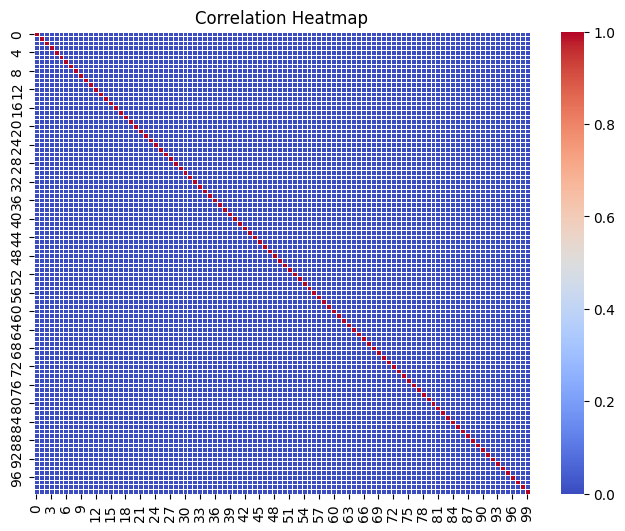

In [64]:
# pd_x_anomali = pd.DataFrame(X_pca[:,:100])
pd_x_anomali = pd.DataFrame(X_pca)
# pd_x_anomali = pd.DataFrame(x_train_normal)
plt.figure(figsize=(8, 6)) # Adjust figure size as needed
sns.heatmap(pd_x_anomali.corr(), cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

In [50]:
# pd_x_normal = pd.DataFrame(X_train_features)
# pd_x_normal.isna().sum().sum()

['bacterial_leaf_blight' 'blast' 'brown_spot' 'normal' 'tungro'] ['red', 'green', 'blue', 'yellow', 'gray']


C:\Users\RYZEN 5\AppData\Local\Temp\ipykernel_3200\1240719168.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_pca_visualizer[:, 0], X_pca_visualizer[:, 1], c=y_color, cmap='viridis', alpha=0.8)


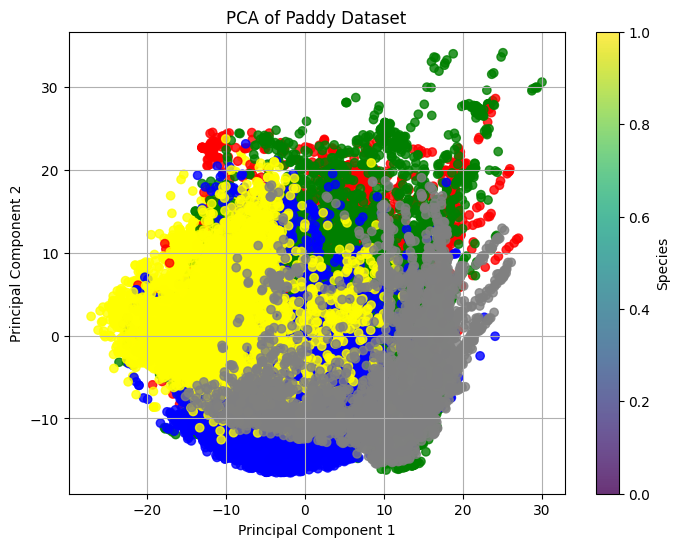

In [65]:
visualizer_pca = PCA(n_components=2)
X_pca_visualizer = visualizer_pca.fit_transform(x_train_normal)

colors = ['red', 'green', 'blue', 'yellow', 'gray']

print(LABELS, colors)

y_color = [colors[np.where(LABELS == label)[0][0]] for label in y_train]

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_visualizer[:, 0], X_pca_visualizer[:, 1], c=y_color, cmap='viridis', alpha=0.8)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Paddy Dataset')
plt.colorbar(label='Species')
plt.grid(True)
plt.show()

In [ ]:
param_grid = {
    'C': [10, 25],
    'gamma': [3e-2, 25e-3],
    'kernel': ['rbf']
}
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
grid_svm = GridSearchCV(SVC(), param_grid, cv=skf)
grid_svm.fit(X_pca, y_train)
# grid_svm.fit(x_train_normal, y_train)

print("Best params:", grid_svm.best_params_)
print("Best score:", grid_svm.best_score_)

Best params: {'C': 25, 'gamma': 0.025, 'kernel': 'rbf'}
Best score: 0.932


In [42]:
pd.DataFrame(grid_svm.cv_results_).sort_values('rank_test_score').head(8)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
3,45.617594,4.092608,22.190786,1.225804,25,0.025,rbf,"{'C': 25, 'gamma': 0.025, 'kernel': 'rbf'}",0.928167,0.934333,0.934667,0.931167,0.931667,0.932000,0.002369,1
1,39.795404,4.350991,21.890004,2.271362,10,0.025,rbf,"{'C': 10, 'gamma': 0.025, 'kernel': 'rbf'}",0.909833,0.915000,0.919000,0.914000,0.913000,0.914167,0.002974,2
2,65.223997,2.608294,38.496204,3.721312,25,0.001,rbf,"{'C': 25, 'gamma': 0.001, 'kernel': 'rbf'}",0.727000,0.728667,0.733000,0.732500,0.728833,0.730000,0.002340,3
0,53.793534,19.439885,39.356000,21.816010,10,0.001,rbf,"{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}",0.697500,0.704167,0.705167,0.706500,0.702500,0.703167,0.003120,4


In [66]:
# Save the model to disk
if not os.path.exists(RESULT_DICT_PATH):
    os.makedirs(RESULT_DICT_PATH)

svm_best_params = [
    {'c':25, 'gamma':0.025},
    {'c':10, 'gamma':0.025},
    {'c':25, 'gamma':0.001},
    {'c':10, 'gamma':0.001},
    {'c':25, 'gamma':0.030},
    {'c':25, 'gamma':0.040},
]
for i, params in enumerate(svm_best_params):
    if os.path.isfile(os.path.join(RESULT_DICT_PATH, f'svm_model_{i}.pkl')): continue #just skipped existing model
    svm_hype = SVC(C=params['c'], gamma=params['gamma'], kernel='rbf', decision_function_shape='ovo')
    svm_hype.fit(X_pca, y_train)
    # svm_hype.fit(x_train_normal, y_train)
    with open(os.path.join(RESULT_DICT_PATH, f'svm_model_{i}.pkl'), 'wb') as file:
        pickle.dump(svm_hype, file)

In [107]:
rf = RandomForestClassifier(n_estimators=100, max_depth=20, max_features='sqrt')
knn = KNeighborsClassifier(n_neighbors=3, weights='uniform')

In [130]:
score_list = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv_rf = cross_validate(rf, X_pca, y_train, scoring=score_list, cv=skf)
cv_knn = cross_validate(knn, X_pca, y_train, scoring=score_list, cv=skf)

In [109]:
pd.DataFrame(cv_rf).describe().loc[['mean', 'std']]

,fit_time,score_time,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
mean,18.764209,0.175593,0.984233,0.984273,0.984233,0.984240
std,0.440730,0.056050,0.001326,0.001299,0.001326,0.001322


In [110]:
pd.DataFrame(cv_knn).describe().loc[['mean', 'std']]

,fit_time,score_time,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
mean,0.025001,1.634293,0.986167,0.986208,0.986167,0.986176
std,0.008124,1.808072,0.001219,0.001204,0.001219,0.001216


In [112]:
rf.fit(X_pca, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [113]:
knn.fit(X_pca, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [114]:
with open(RF_MODEL_PATH, 'wb') as file:
    pickle.dump(rf, file)

with open(KNN_MODEL_PATH, 'wb') as file:
    pickle.dump(knn, file)

                       precision    recall  f1-score   support

bacterial_leaf_blight     0.9709    1.0000    0.9852       200
                blast     0.9848    0.9750    0.9799       200
           brown_spot     0.9900    0.9900    0.9900       200
               normal     1.0000    0.9850    0.9924       200
               tungro     0.9899    0.9850    0.9875       200

             accuracy                         0.9870      1000
            macro avg     0.9871    0.9870    0.9870      1000
         weighted avg     0.9871    0.9870    0.9870      1000

Confusion Matrix for SVM:


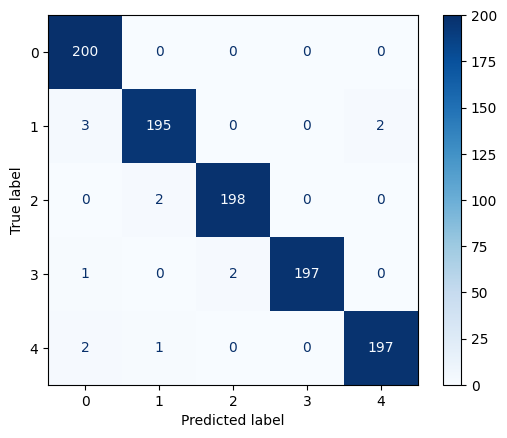

In [118]:
y_pred = rf.predict(X_pca_test)
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix for SVM:")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
print("="*50)

In [53]:
y_pred = knn.predict(X_pca_test)
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix for SVM:")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
print("="*50)

NameError: name 'knn' is not defined

In [98]:
# svm = SVC(kernel='rbf', C=100.0, gamma=0.001)
# skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
# scores = cross_validate(svm, X_pca, y_train, cv=skf, scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'], return_train_score=True)
# print("Cross-validation results:")
# print(f"Mean Accuracy: {np.mean(scores['test_accuracy']):.4f} ± {np.std(scores['test_accuracy']):.4f}")
# print(f"Mean Precision: {np.mean(scores['test_precision_macro']):.4f} ± {np.std(scores['test_precision_macro']):.4f}")
# print(f"Mean Recall: {np.mean(scores['test_recall_macro']):.4f} ± {np.std(scores['test_recall_macro']):.4f}")
# print(f"Mean F1 Score: {np.mean(scores['test_f1_macro']):.4f} ± {np.std(scores['test_f1_macro']):.4f}")


In [99]:
# svm.fit(X_pca, y_train)

                       precision    recall  f1-score   support

bacterial_leaf_blight     0.9802    0.9900    0.9851       200
                blast     0.9701    0.9750    0.9726       200
           brown_spot     0.9898    0.9750    0.9824       200
               normal     1.0000    1.0000    1.0000       200
               tungro     1.0000    1.0000    1.0000       200

             accuracy                         0.9880      1000
            macro avg     0.9880    0.9880    0.9880      1000
         weighted avg     0.9880    0.9880    0.9880      1000

Confusion Matrix for SVM:


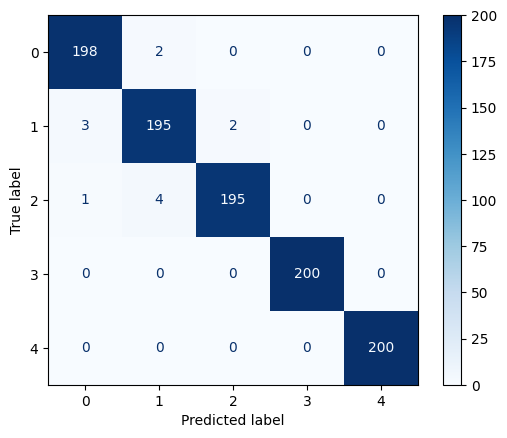

In [71]:
with open(os.path.join(RESULT_DICT_PATH, f'svm_model_2.pkl'), 'rb') as model_file:
# with open(os.path.join('Results/250914 1830 Mixed On Field No Duplicate Normal Indo', f'svm_model.pkl'), 'rb') as model_file:
    svm = pickle.load(model_file)

# svm = SVC(kernel='rbf')
# svm.fit(X_pca, y_train)
y_pred = svm.predict(X_pca_test)
# y_pred = svm.predict(x_test_normal)
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix for SVM:")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
print("="*50)

In [70]:
# Save the model to disk
if not os.path.exists(RESULT_DICT_PATH):
    os.makedirs(RESULT_DICT_PATH)

with open(SCALER_PATH, 'wb') as file:
    pickle.dump(scaler, file)
    
with open(PCA_PATH, 'wb') as file:
    pickle.dump(my_pca, file)
    
# with open(SVM_MODEL_PATH, 'wb') as file:
#     pickle.dump(svm, file)

In [56]:
def extract_features_advanced(image_np_array):
    """
    Args:
        image_np_array (numpy.ndarray): Gambar yang akan diekstraksi fiturnya.

    Returns:
        numpy.ndarray: Vektor fitur 1D dari gambar.
    """
    
    image = cv2.resize(image_np_array, IMG_SIZE)
    # color_moments = calculate_color_moments(image)
    color_hist_hsv = calculate_histogram(cv2.cvtColor(image, cv2.COLOR_BGR2HSV), channels=[0, 1, 2])
    color_moments = calculate_color_moments(image)
    texture_features_n_hog = calculate_texture_features_n_hog(image)
    
    
    # return np.concatenate((color_hist_hsv, hu_moments, texture_features_n_hog))
    # return np.concatenate((color_hist_hsv, texture_features_n_hog))
    return np.concatenate((color_hist_hsv, color_moments, texture_features_n_hog))
    # return np.concatenate((color_moments, color_moments_hsv, color_moments_lab, texture_features_n_hog))

In [57]:
def test_model_performance(test_data_dir, model_path, scaler_path, pca_path, classes):
    """
    Menguji model SVM yang telah disimpan dan menghitung performa serta durasi.

    Args:
        test_data_dir (str): Path ke folder yang berisi gambar untuk diuji.
        model_path (str): Path ke file model SVM yang disimpan.
        scaler_path (str): Path ke file scaler (StandardScaler) yang disimpan.
        classes (list): Daftar nama kelas (string).
    """
    print("--- Memulai Pengujian Performa Model ---")
    start_total_time = time.time()

    # --- 1. Memuat Model dan Scaler ---
    print(f"\n[{time.strftime('%H:%M:%S', time.localtime())}] Memuat model dan scaler...")
    try:
        with open(model_path, 'rb') as model_file:
            model = pickle.load(model_file)
        with open(scaler_path, 'rb') as scaler_file:
            scaler = pickle.load(scaler_file)
        with open(pca_path, 'rb') as pca_file:
            pca = pickle.load(pca_file)
    except FileNotFoundError as e:
        print(f"Error: {e}. Pastikan path model dan scaler sudah benar.")
        return
    print(f"[{time.strftime('%H:%M:%S', time.localtime())}] Model dan scaler berhasil dimuat.")

    # --- 2. Mengumpulkan Path dan Label Gambar Uji ---
    X_test_paths = []
    y_true_labels = []
    for class_name in classes:
        class_path = os.path.join(test_data_dir, class_name)
        if not os.path.isdir(class_path):
            print(f"Peringatan: Folder '{class_path}' tidak ditemukan. Lewati.")
            continue
        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                X_test_paths.append(os.path.join(class_path, img_name))
                y_true_labels.append(class_name)
    
    if not X_test_paths:
        print("Error: Tidak ada gambar yang ditemukan di direktori uji.")
        return

    # --- 3. Melakukan Prediksi dan Mengukur Waktu per Tahap ---
    y_pred_labels = []
    
    total_time_load_img = 0
    total_time_extract_feat = 0
    total_time_scale_feat = 0
    total_time_predict = 0

    print(f"\n[{time.strftime('%H:%M:%S', time.localtime())}] Memulai loop prediksi untuk {len(X_test_paths)} gambar...")

    for i, img_path in enumerate(X_test_paths):
        # Memuat gambar
        start_stage = time.time()
        img = cv2.imread(img_path)
        end_stage = time.time()
        total_time_load_img += (end_stage - start_stage)
        
        # Preprocessing dan ekstraksi fitur
        start_stage = time.time()
        features = extract_features_advanced(img)
        end_stage = time.time()
        total_time_extract_feat += (end_stage - start_stage)
        
        # Scaling fitur
        start_stage = time.time()
        # Perhatikan: reshape(-1, 1) jika hanya 1 fitur, atau [features] jika banyak fitur
        # scaler.transform membutuhkan input 2D
        scaled_features = scaler.transform(features.reshape(1, -1))
        end_stage = time.time()
        total_time_scale_feat += (end_stage - start_stage)
        
        # PCA fitur
        start_stage = time.time()
        pca_features = pca.transform(scaled_features)
        end_stage = time.time()
        total_time_scale_feat += (end_stage - start_stage)
        
        # Prediksi
        start_stage = time.time()
        prediction = model.predict(pca_features)
        # prediction = model.predict(scaled_features)
        y_pred_labels.append(prediction[0])
        end_stage = time.time()
        total_time_predict += (end_stage - start_stage)

        if (i + 1) % 100 == 0 or (i + 1) == len(X_test_paths):
            print(f"[{time.strftime('%H:%M:%S', time.localtime())}] Selesai memproses {i + 1}/{len(X_test_paths)} gambar.")

    end_total_time = time.time()
    total_duration = end_total_time - start_total_time

    # --- 4. Menampilkan Hasil ---
    print("\n--- Hasil Evaluasi ---")
    accuracy = accuracy_score(y_true_labels, y_pred_labels)
    print(f"Akurasi Prediksi Keseluruhan: {accuracy:.4f}")

    print("\n--- Ringkasan Durasi Waktu ---")
    print(f"Total Waktu Keseluruhan: {total_duration:.4f} detik")
    print(f"Total Gambar Dites: {len(X_test_paths)}")
    print(f"\nDurasi Rata-rata per Gambar:")
    print(f"  - Memuat Gambar: {total_time_load_img / len(X_test_paths):.6f} detik")
    print(f"  - Ekstraksi Fitur: {total_time_extract_feat / len(X_test_paths):.6f} detik")
    print(f"  - Scaling Fitur: {total_time_scale_feat / len(X_test_paths):.6f} detik")
    print(f"  - Prediksi Model: {total_time_predict / len(X_test_paths):.6f} detik")
    
    print(classification_report(y_true_labels, y_pred_labels, digits=4))
    cm = confusion_matrix(y_true_labels, y_pred_labels)
    print(f"Confusion Matrix for SVM:")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    print("="*50)

--- Memulai Pengujian Performa Model ---

[06:05:05] Memuat model dan scaler...
[06:05:05] Model dan scaler berhasil dimuat.

[06:05:05] Memulai loop prediksi untuk 67 gambar...
[06:05:17] Selesai memproses 67/67 gambar.

--- Hasil Evaluasi ---
Akurasi Prediksi Keseluruhan: 0.0000

--- Ringkasan Durasi Waktu ---
Total Waktu Keseluruhan: 11.4210 detik
Total Gambar Dites: 67

Durasi Rata-rata per Gambar:
  - Memuat Gambar: 0.104911 detik
  - Ekstraksi Fitur: 0.055910 detik
  - Scaling Fitur: 0.000732 detik
  - Prediksi Model: 0.008357 detik
              precision    recall  f1-score   support

  brown_spot     0.0000    0.0000    0.0000       0.0
      normal     0.0000    0.0000    0.0000      67.0

    accuracy                         0.0000      67.0
   macro avg     0.0000    0.0000    0.0000      67.0
weighted avg     0.0000    0.0000    0.0000      67.0

Confusion Matrix for SVM:


c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: 

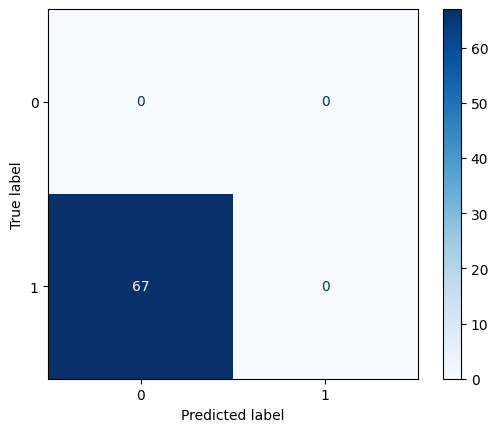

In [74]:
test_model_performance(TEST_DATA_PATH, os.path.join(RESULT_DICT_PATH, 'svm_model_5.pkl'), SCALER_PATH, PCA_PATH, LABELS)
# test_model_performance(TEST_DATA_PATH, SVM_MODEL_PATH, SCALER_PATH, PCA_PATH, LABELS)
# test_model_performance(TEST_DATA_PATH, SVM_MODEL_PATH, SCALER_PATH, PCA_PATH, LABELS)
# test_model_performance(TEST_DATA_PATH, 'Results/250902 2018 Mixed On Field No Duplicate Normal Indo (best acc)/svm_model.pkl', 'Results/250902 2018 Mixed On Field No Duplicate Normal Indo (best acc)/scaler.pkl', PCA_PATH, LABELS)